In [2]:
from src import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

data = get_combined_data()
sim_params = SimulationParameters("default_1")
sim_handler = SimulatorHandler()
gap_handler = sim_handler.simulation_gap(sim_params, data)

The target default_1 already exists and will be overwritten


In [3]:
action_gaps = {"combined" : []}
for action, gap_datas in gap_handler._sim_gap_data.items():
    action_gaps[action] = []
    for gap_data in gap_datas:
        gap = gap_data.get_total_gap_avg()
        action_gaps[action].append(gap)
        action_gaps["combined"].append(gap)
for gaps in action_gaps.values():
    gaps.sort()
for action, gaps in action_gaps.items():
    p_25 = np.percentile(gaps, 25)
    p_50 = np.percentile(gaps, 50)
    p_75 = np.percentile(gaps, 75)
    print(action + ": " + str(p_25) + ", " + str(p_50) + ", " + str(p_75))

combined: 0.009221440717539806, 0.011052022291198636, 0.02044741237557145
kick_left: 0.016571523651166424, 0.018155279505123634, 0.020582784212973736
kick_right: 0.020439007987428166, 0.021974985077285285, 0.025031657529619097
walk_front: 0.007674198812662713, 0.008291482718639852, 0.009978473115569621
walk_back: 0.009201167667192839, 0.009558156030000618, 0.011411691270279821
sidestep_left: 0.008970189151550302, 0.00951374247714451, 0.00989705236863175
sidestep_right: 0.008583501699818542, 0.00876805072750311, 0.0092168241401567
turn_left: 0.008802110692114631, 0.009537297463763068, 0.010233699371205912
turn_right: 0.009421218616278454, 0.00965184577674648, 0.010442830778518358
standup_back: 0.021667562961187693, 0.024381634893002865, 0.0355148716756207
standup_front: 0.023123978939401792, 0.02957368872468917, 0.03727711952565197


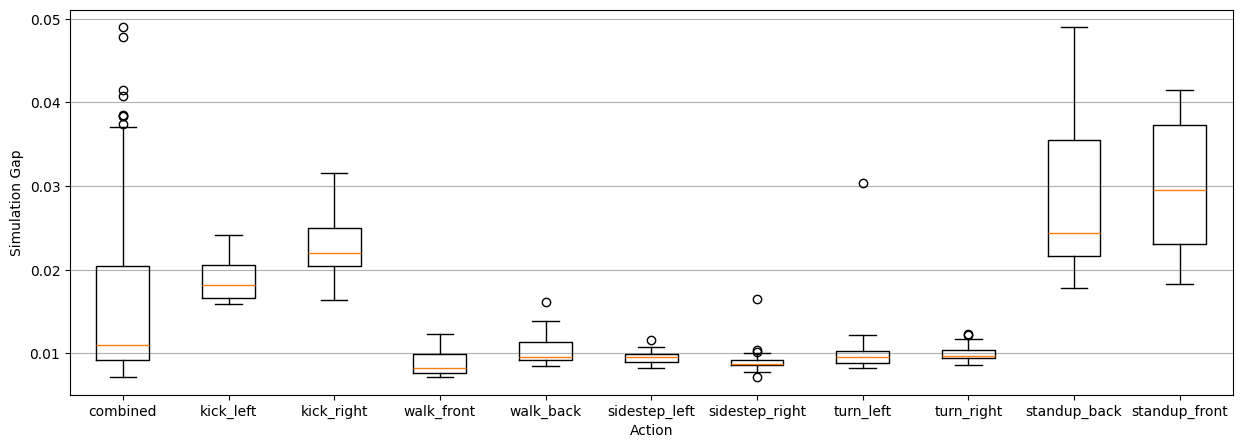

In [13]:
plt.figure(figsize=(15,5))
plt.xlabel("Action")
plt.ylabel("Simulation Gap")
plt.grid(visible=True, axis="y")
plt.boxplot(action_gaps.values(), tick_labels=action_gaps.keys())
plt.savefig("action_gaps.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

kick_left


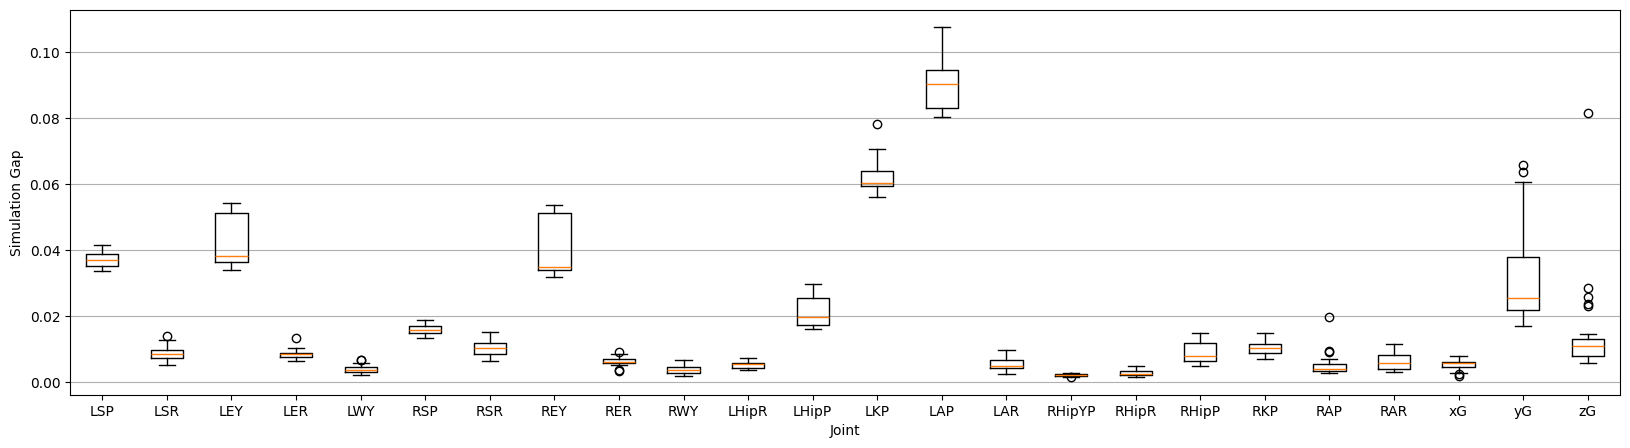

kick_right


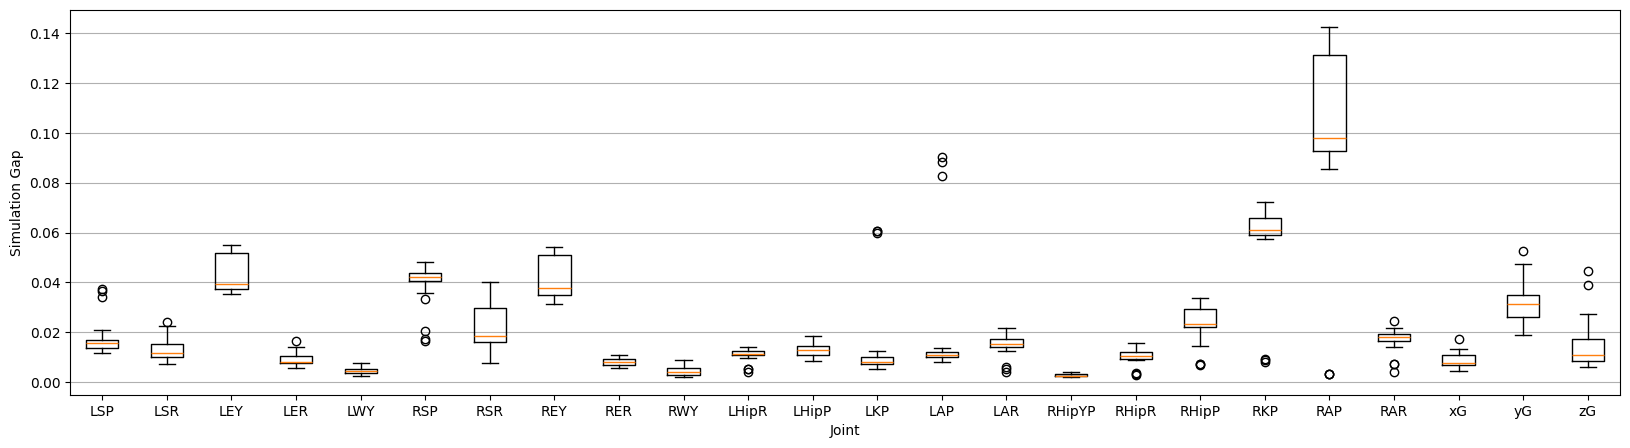

walk_front


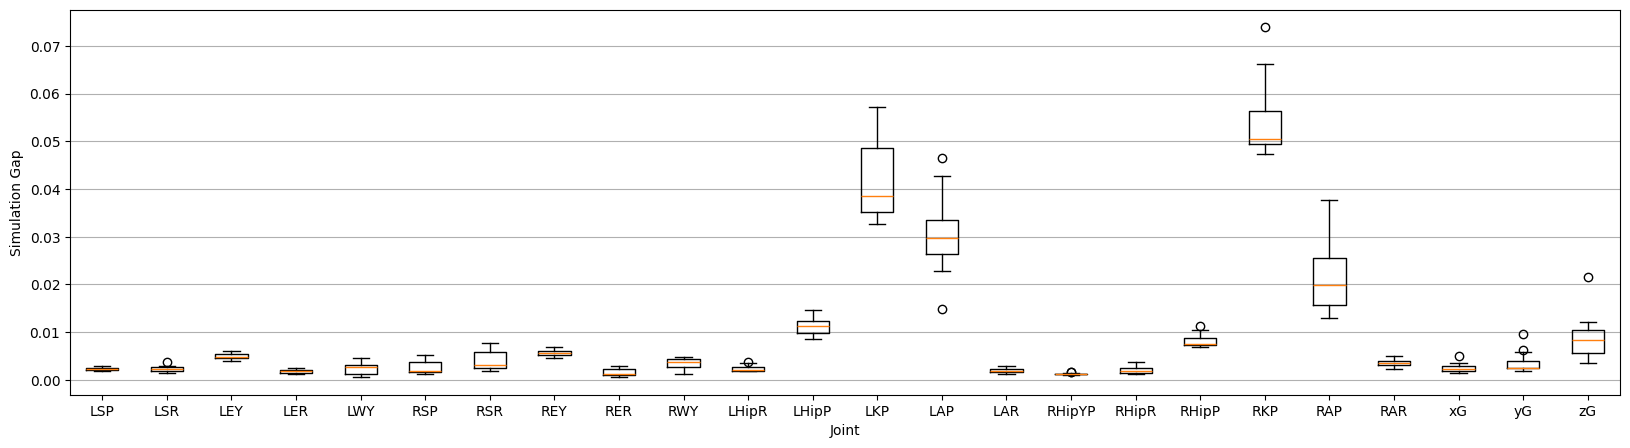

walk_back


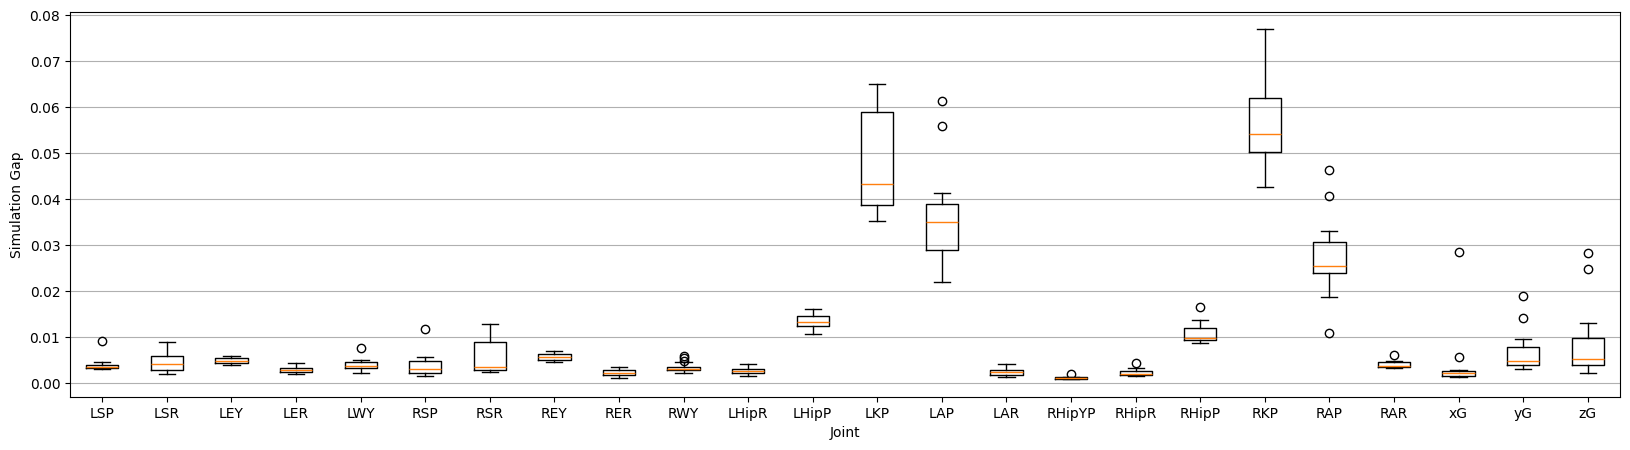

sidestep_left


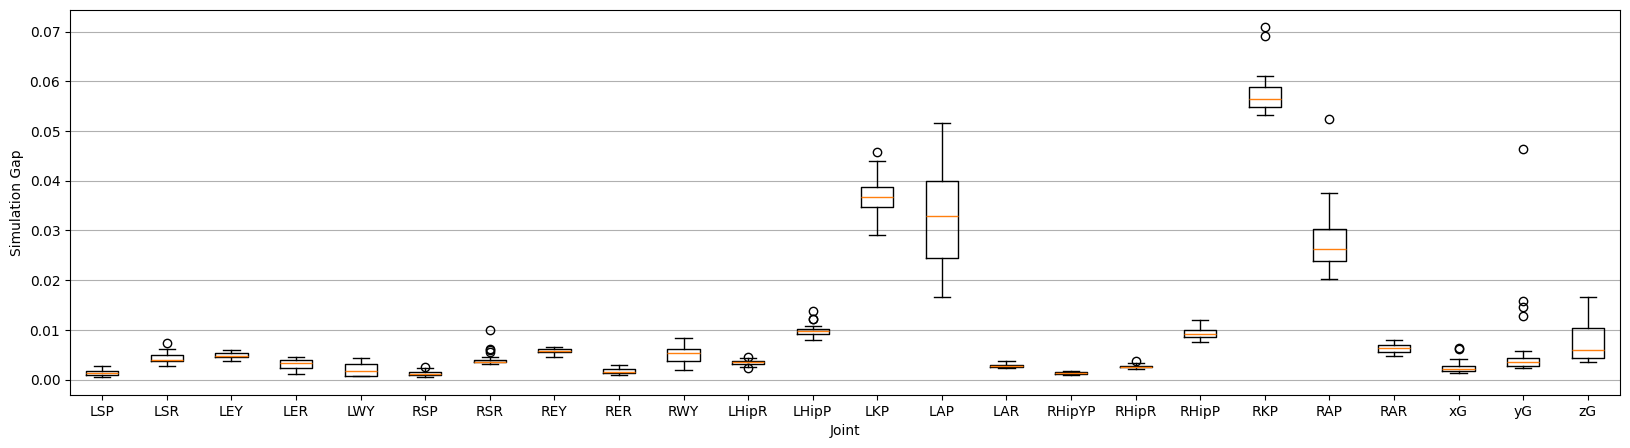

sidestep_right


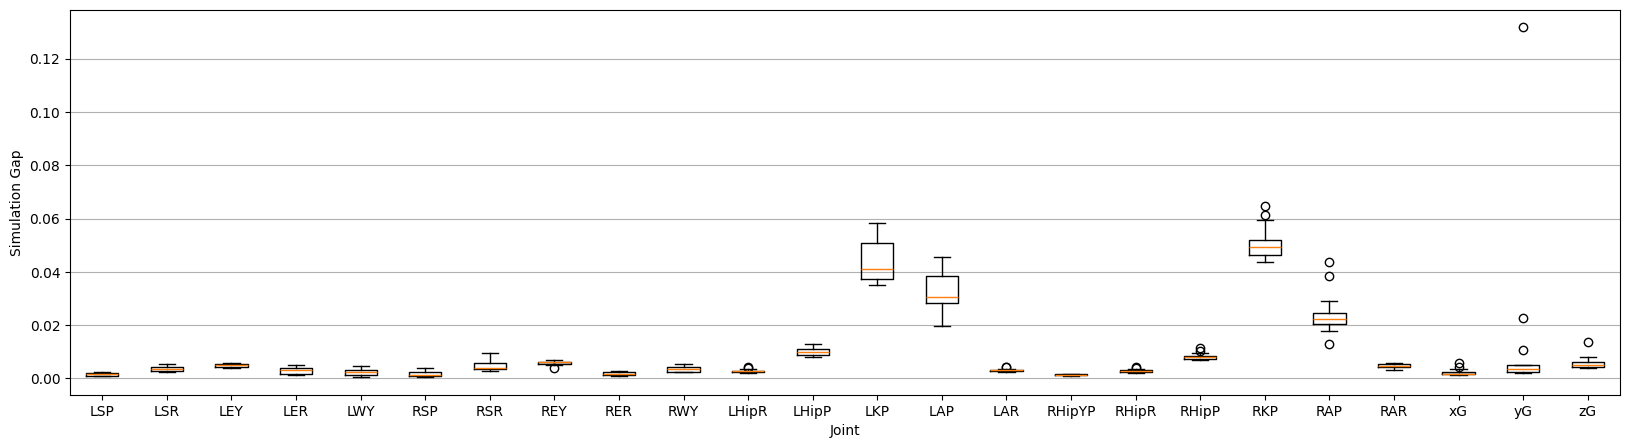

turn_left


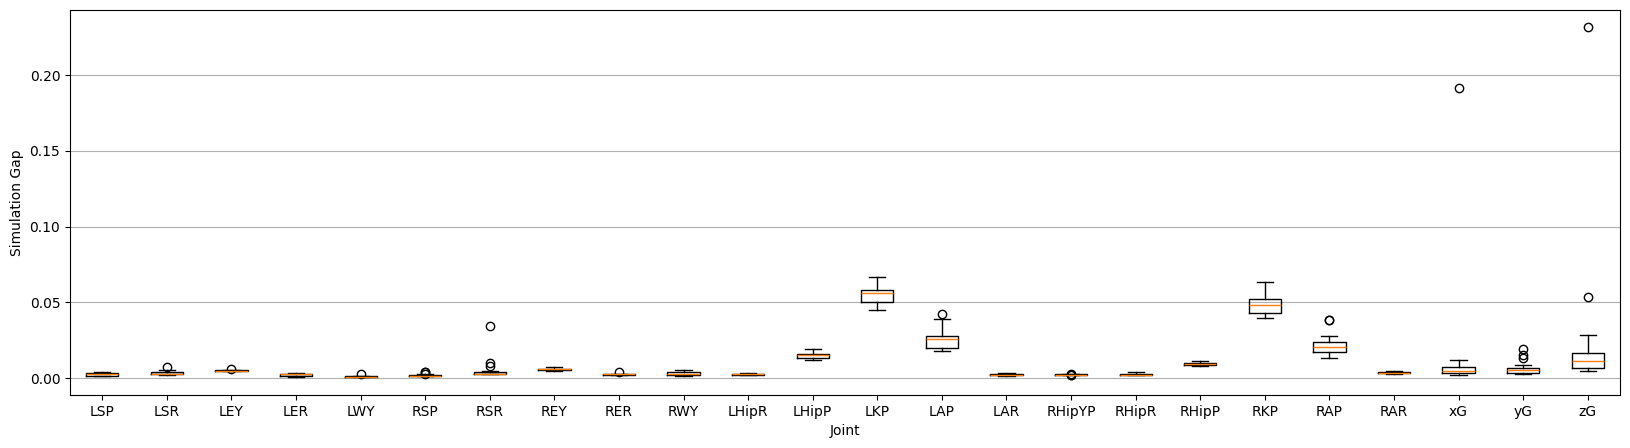

turn_right


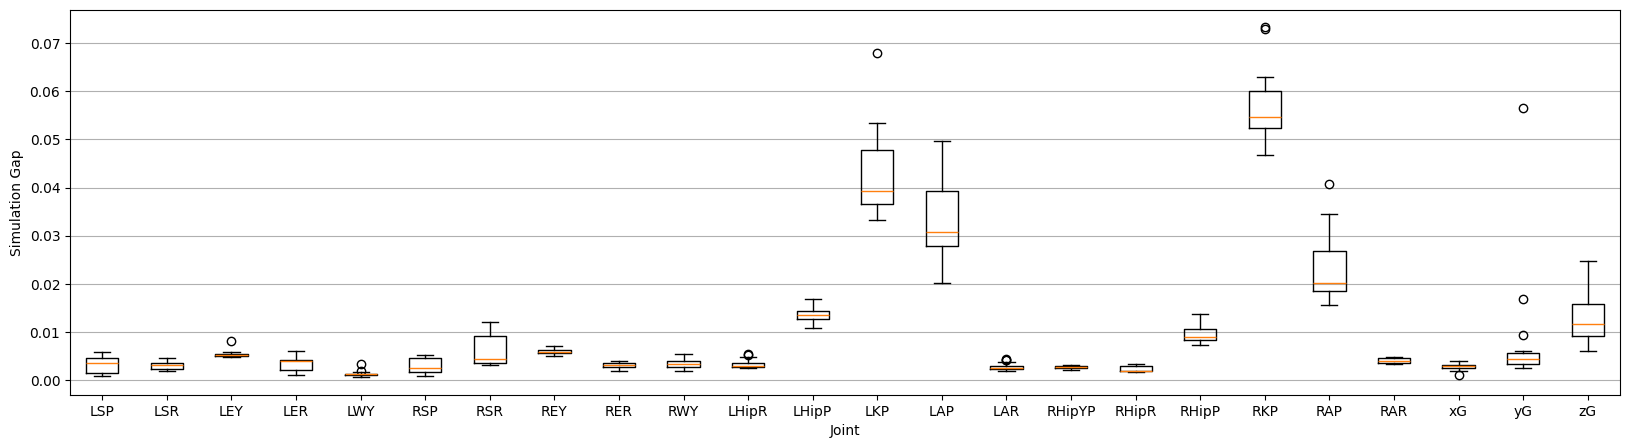

standup_back


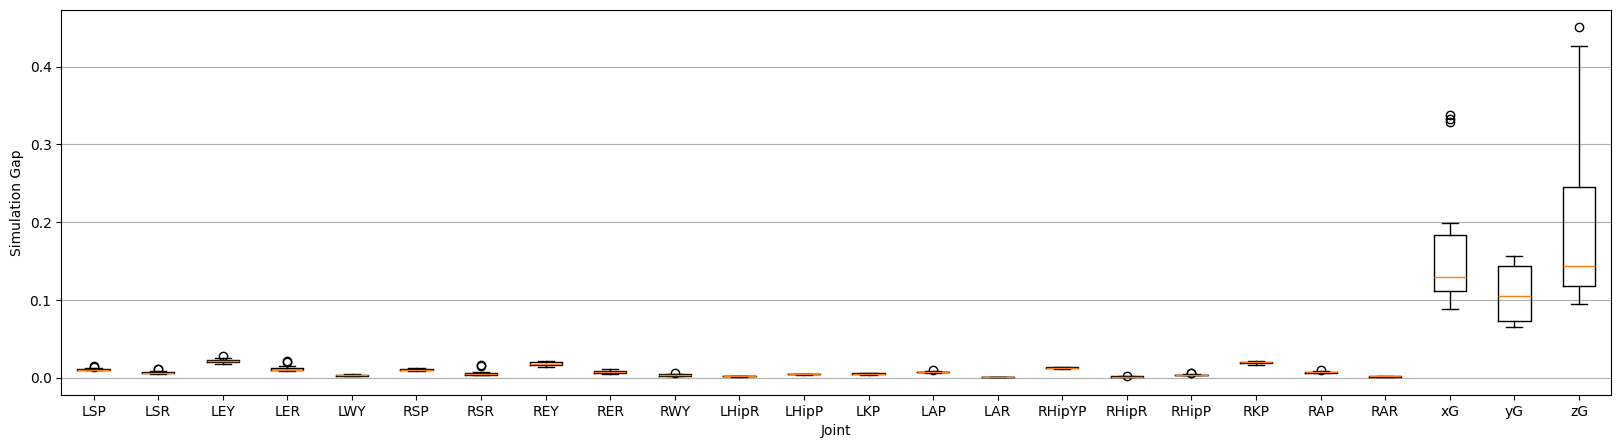

standup_front


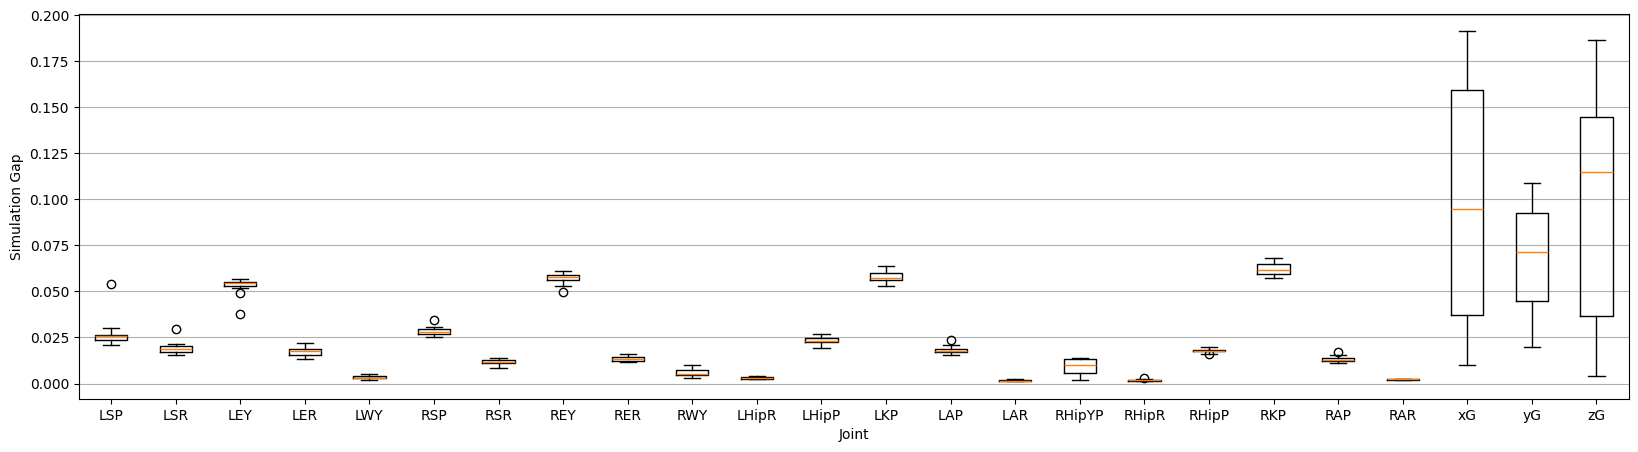

In [11]:
excluded_sensors = ["headYaw", "headPitch", "lHipYawPitch"]

for action, gap_datas in gap_handler._sim_gap_data.items():
    sensor_gaps = {}
    for gap_data in gap_datas:
        sensor_gap = gap_data.get_total_gap_for_sensors()
        for key,value in sensor_gap.items():
            if key in excluded_sensors:
                continue
            if not key in sensor_gaps.keys():
                sensor_gaps[key] = []
            sensor_gaps[key].append(sensor_gap[key])
    print(action)
    plt.figure(figsize=(20, 5))
    plt.xlabel("Joint")
    plt.ylabel("Simulation Gap")
    plt.grid(visible=True, axis="y")
    plt.boxplot(sensor_gaps.values(), tick_labels=[ABBREVIATIONS[key] for key in sensor_gaps.keys()])
    plt.show()

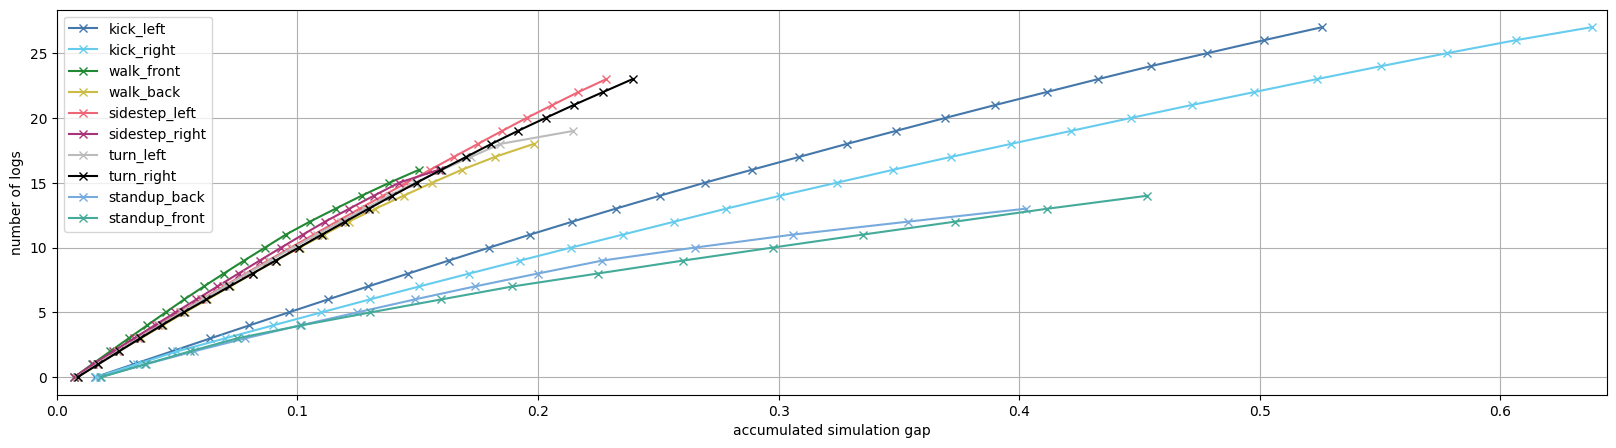

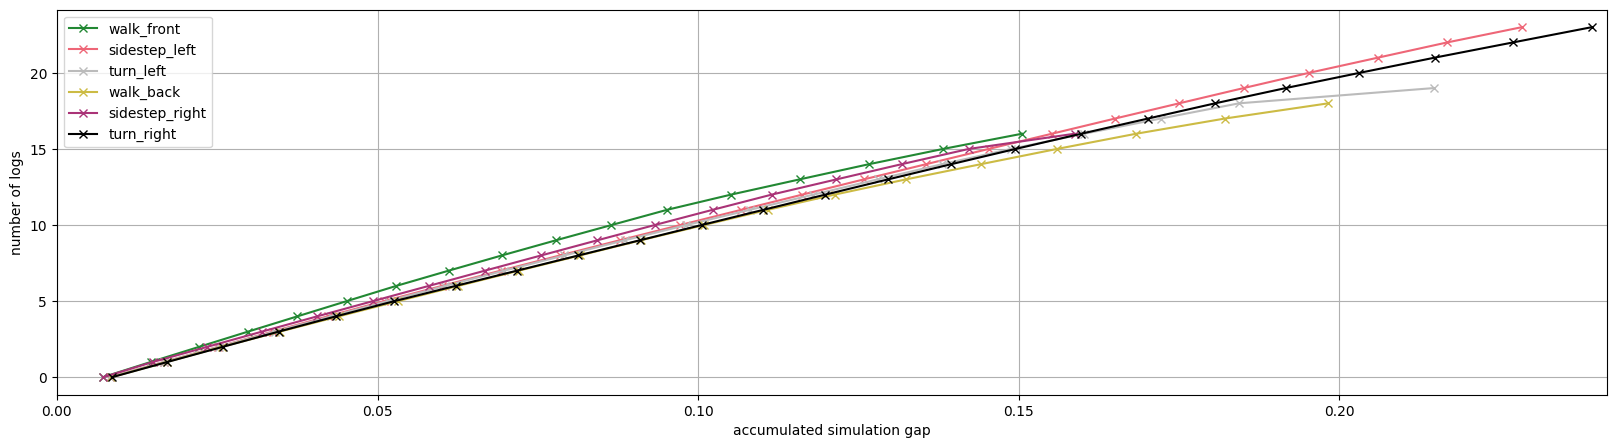

In [4]:
accumulated_gaps = {}
for action, gaps in action_gaps.items():
    accumulated_gaps[action] = np.cumsum(gaps)
gaps_y_axis = {action : list(range(0, len(gaps))) for action, gaps in accumulated_gaps.items()}


keys = accumulated_gaps.keys()
max_value = max([accumulated_gap[-1] for action, accumulated_gap in accumulated_gaps.items() if action in keys])
keys_2 = ["walk_front","sidestep_left","turn_left","walk_back","sidestep_right","turn_right"]
max_value_2 = max([accumulated_gap[-1] for action, accumulated_gap in accumulated_gaps.items() if action in keys_2])

plt.figure(figsize=(20, 5))
plt.xlabel("accumulated simulation gap")
plt.ylabel("number of logs")
plt.xlim(0, max_value*1.01)
plt.grid(visible=True)
for action in keys:
    accumulated_gap = accumulated_gaps[action]
    y_axis = gaps_y_axis[action]
    plt.plot(accumulated_gap, y_axis, label=action, color = COLORS[action], marker = "x")
plt.legend()
plt.show()

plt.figure(figsize=(20, 5))
plt.xlabel("accumulated simulation gap")
plt.ylabel("number of logs")
plt.grid(visible=True)
for action in keys_2:
    accumulated_gap = accumulated_gaps[action]
    y_axis = gaps_y_axis[action]
    plt.plot(accumulated_gap, y_axis, label=action, color = COLORS[action], marker = "x")
plt.xlim(0, max_value_2*1.01)
plt.legend()
plt.show()